In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv(r'ecommerce_dataset.csv')

In [4]:
df.head(10)

,order_id,product,category,price,quantity,payment_method,date,total,Month,Discount,City Code,Order Priority Code,Latitude,Longtitude
0,1,Watch,Electronics,12652.30,4,Easypaisa,01/01/2023,50609.20,January,0.0,1.0,2.0,1.0,0.0
1,2,Bag,Fashion,20053.64,2,Credit Card,02/01/2023,40107.28,January,0.1,1.0,2.0,1.0,0.0
2,3,Shoes,Fashion,13274.17,2,JazzCash,03/01/2023,26548.34,January,0.1,1.0,2.0,1.0,0.0
3,4,Bag,Electronics,15332.08,1,COD,04/01/2023,15332.08,January,0.1,1.0,2.0,1.0,0.0
4,5,Bag,Accessories,23165.07,1,Debit Card,05/01/2023,23165.07,January,0.0,1.0,NaN,1.0,0.0
5,6,Laptop,Fashion,14283.20,4,JazzCash,06/01/2023,57132.80,January,0.1,1.0,2.0,1.0,0.0
6,7,Shoes,Fashion,71792.85,3,JazzCash,07/01/2023,215378.55,January,0.0,1.0,2.0,1.0,0.0
7,8,Shoes,Fashion,6878.58,2,Debit Card,08/01/2023,13757.16,January,0.0,NaN,2.0,1.0,0.0
8,9,Shoes,Electronics,42198.66,2,JazzCash,09/01/2023,84397.32,January,0.0,1.0,2.0,1.0,0.0
9,10,Bag,Fashion,33126.55,1,COD,10/01/2023,33126.55,January,0.2,1.0,2.0,1.0,0.0


In [5]:
df.shape

(506, 14)

In [7]:
df.dtypes

order_id                 int64
product                 object
category                object
price                  float64
quantity                 int64
payment_method          object
date                    object
total                  float64
Month                   object
Discount               float64
City Code              float64
Order Priority Code    float64
Latitude               float64
Longtitude             float64
dtype: object

In [10]:
df.describe()

,order_id,price,quantity,total,Discount,City Code,Order Priority Code,Latitude,Longtitude
count,506.000000,506.000000,506.000000,506.000000,506.000000,491.000000,487.000000,506.000000,506.000000
mean,247.697628,40364.931779,2.551383,102690.135731,0.356953,3.429735,1.655031,0.966522,-0.615810
std,145.888325,25009.534303,1.161396,80765.613813,0.260781,1.656358,1.165383,0.198660,2.356904
min,1.000000,1374.170000,1.000000,1533.650000,0.000000,1.000000,0.000000,-0.210000,-9.100000
25%,121.250000,18740.542500,2.000000,36685.035000,0.150000,2.000000,1.000000,1.000000,0.000000
50%,247.500000,40272.370000,2.500000,78100.345000,0.350000,3.000000,2.000000,1.000000,0.000000
75%,373.750000,60670.212500,4.000000,151711.150000,0.700000,5.000000,3.000000,1.000000,0.000000
max,500.000000,234567.000000,7.000000,493704.610000,0.850000,6.000000,3.000000,1.000000,1.000000


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   order_id             506 non-null    int64  
 1   product              506 non-null    object 
 2   category             506 non-null    object 
 3   price                506 non-null    float64
 4   quantity             506 non-null    int64  
 5   payment_method       506 non-null    object 
 6   date                 506 non-null    object 
 7   total                506 non-null    float64
 8   Month                506 non-null    object 
 9   Discount             506 non-null    float64
 10  City Code            491 non-null    float64
 11  Order Priority Code  487 non-null    float64
 12  Latitude             506 non-null    float64
 13  Longtitude           506 non-null    float64
dtypes: float64(7), int64(2), object(5)
memory usage: 55.5+ KB


In [12]:
print(df.dtypes)

order_id                 int64
product                 object
category                object
price                  float64
quantity                 int64
payment_method          object
date                    object
total                  float64
Month                   object
Discount               float64
City Code              float64
Order Priority Code    float64
Latitude               float64
Longtitude             float64
dtype: object


In [15]:
df =  df.drop(columns=["Latitude" , "Longtitude"])
df = df.rename(columns={

                     "City Code" : "City",
                     "Order Priority Code" : "Order Priority"

    
})

In [16]:
print(df.columns)
print(df.shape)

Index(['order_id', 'product', 'category', 'price', 'quantity',
       'payment_method', 'date', 'total', 'Month', 'Discount', 'City',
       'Order Priority'],
      dtype='object')
(506, 12)


In [17]:
print("Duplicate row" , df.duplicated().sum())


print("Showing")
print(df[df.duplicated()])

df = df.drop_duplicates().reset_index(drop=True)

print("New shape" , df.shape)




Duplicate row 6
Showing
     order_id     product     category     price  quantity payment_method  \
500         3       Shoes      Fashion  13274.17         2       JazzCash   
501         4         Bag  Electronics  15332.08         1            COD   
502        18  Headphones  Electronics  14085.56         2     Debit Card   
503        19      Laptop  Accessories  53657.14         4     Debit Card   
504        20       Watch      Fashion  74385.39         4    Credit Card   
505        21         Bag  Electronics  44762.65         4            COD   

           date      total    Month  Discount  City  Order Priority  
500  03/01/2023   26548.34  January       0.1   1.0             2.0  
501  04/01/2023   15332.08  January       0.1   1.0             2.0  
502  18/01/2023   28171.12  January       0.0   1.0             2.0  
503  19/01/2023  214628.56  January       0.1   1.0             2.0  
504  20/01/2023  297541.56  January       0.0   1.0             2.0  
505  21/01/2023 

In [18]:
print(df.isnull().sum())

order_id           0
product            0
category           0
price              0
quantity           0
payment_method     0
date               0
total              0
Month              0
Discount           0
City              15
Order Priority    19
dtype: int64


In [19]:


df['City'] = df['City'].fillna(df['City'].median())
df['Order Priority'] = df['Order Priority'].fillna(df['Order Priority'].median())

df['City'] = df['City'].astype(int)
df['Order Priority'] = df['Order Priority'].astype(int)

print("Total missing after fill:", df.isnull().sum().sum())
print(df.dtypes)

Total missing after fill: 0
order_id            int64
product            object
category           object
price             float64
quantity            int64
payment_method     object
date               object
total             float64
Month              object
Discount          float64
City                int64
Order Priority      int64
dtype: object


In [20]:
city_map = {
    1: 'Karachi',
    2: 'Lahore',
    3: 'Islamabad',
    4: 'Faisalabad',
    5: 'Quetta',
    6: 'Peshawar'
}

df['City'] = df['City'].map(city_map)

# 
print(df['City'].value_counts())

City
Lahore        140
Quetta         97
Islamabad      92
Peshawar       71
Faisalabad     52
Karachi        48
Name: count, dtype: int64


In [21]:
priority_map = {0: 'LOW', 1: 'MEDIUM', 2: 'HIGH', 3: 'CRITICAL'}
df['Order Priority'] = df['Order Priority'].map(priority_map)

In [22]:
df.to_csv('ecommerce_clean.csv', index=False)

product
Headphones    9414259.95
Watch         9295181.97
Mobile        8478520.28
Shoes         8304435.17
Laptop        7908062.14
Name: total, dtype: float64


C:\Users\Dell\AppData\Local\Temp\ipykernel_9456\1647942781.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top5.index, y=top5.values, palette='viridis')


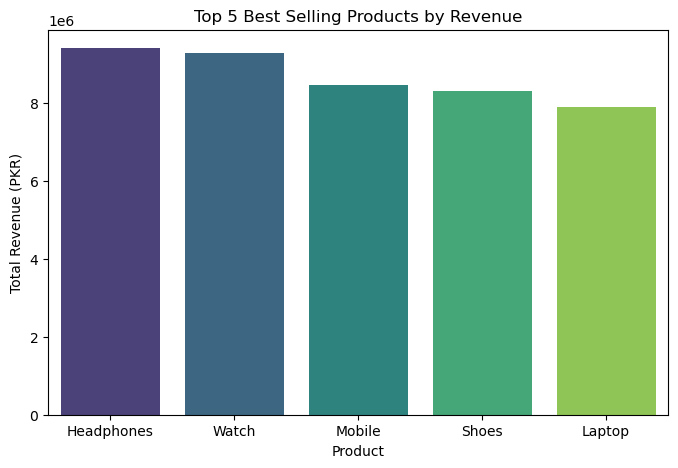

In [23]:
top5 = df.groupby('product')['total'].sum().sort_values(ascending=False).head(5)
print(top5)

plt.figure(figsize=(8, 5))
sns.barplot(x=top5.index, y=top5.values, palette='viridis')
plt.title('Top 5 Best Selling Products by Revenue')
plt.xlabel('Product')
plt.ylabel('Total Revenue (PKR)')
plt.show()

payment_method
JazzCash       112
Credit Card    107
Easypaisa      105
COD             97
Debit Card      79
Name: count, dtype: int64


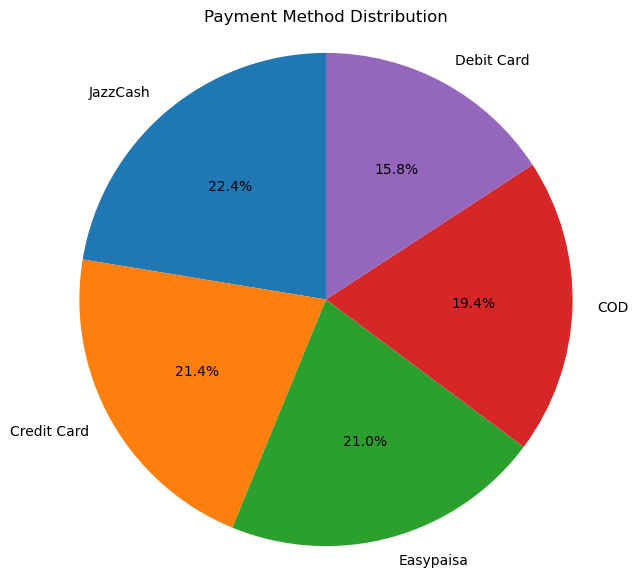

In [24]:
payment_counts = df['payment_method'].value_counts()
print(payment_counts)

plt.figure(figsize=(7, 7))
plt.pie(payment_counts.values,
        labels=payment_counts.index,
        autopct='%1.1f%%',
        startangle=90)
plt.title('Payment Method Distribution')
plt.axis('equal')
plt.show()

Month
January      6238414.59
February     5545040.22
March        6711119.66
April        6275753.74
May          5909845.92
June         2860920.11
July         2688475.62
August       2557288.54
September    2515916.08
October      3139444.82
November     2805153.37
December     3952563.75
Name: total, dtype: float64


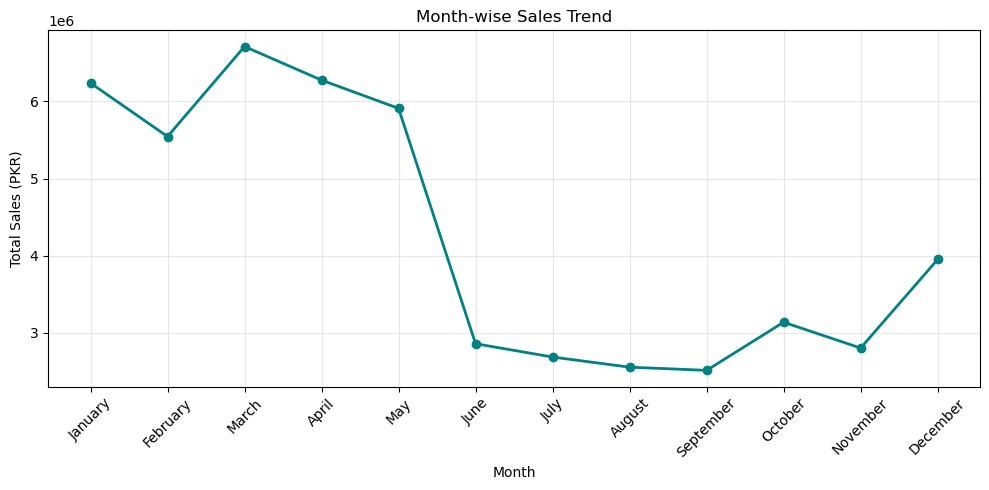

In [25]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

monthly_sales = df.groupby('Month')['total'].sum().reindex(month_order)
print(monthly_sales)

plt.figure(figsize=(10, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', linewidth=2, color='teal')
plt.title('Month-wise Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales (PKR)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Total sales peak in March (PKR 6.71M) and are consistently strong from January to May, then drop sharply from June onward, with September the lowest at PKR 2.52M. However, this apparent decline is misleading. Order counts fall from approximately 60 per month in January–April to exactly 30–31 per month from June to December, suggesting the second half of the year is under-recorded rather than genuinely weaker. Average order value confirms this: it remains stable throughout the year (PKR 82,000–131,000) with no corresponding collapse. December shows a clear recovery to PKR 3.95M — the highest in the second half — along with the year's second-highest average order value (PKR 127,502), consistent with year-end and holiday-season buying. May also stands out with the highest average order value of the year (PKR 131,330) despite fewer orders, indicating higher-value purchases. Recommendation: verify data collection for June–December before treating the mid-year decline as a real business trend.

City
Lahore        14665005.16
Quetta         9488620.43
Islamabad      9472379.53
Faisalabad     6318998.97
Peshawar       6194016.19
Karachi        5060916.14
Name: total, dtype: float64


C:\Users\Dell\AppData\Local\Temp\ipykernel_9456\898882246.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_sales.values, y=city_sales.index, palette='mako')


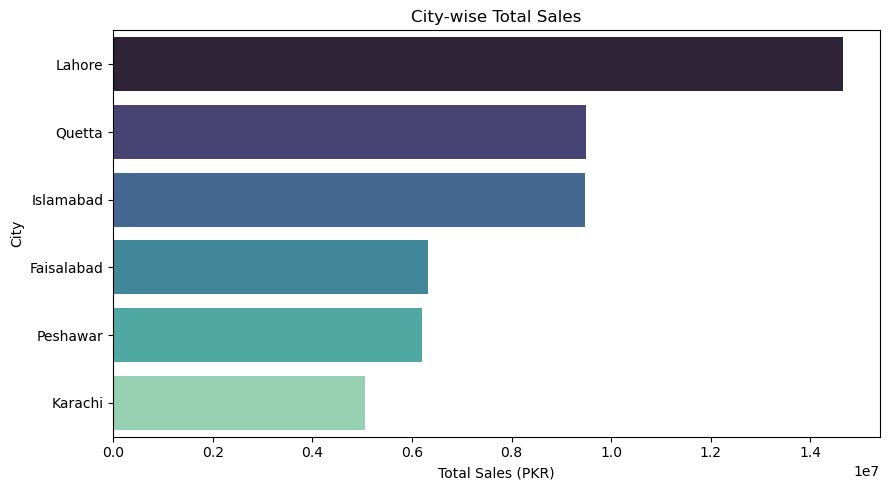

In [26]:
city_sales = df.groupby('City')['total'].sum().sort_values(ascending=False)
print(city_sales)

plt.figure(figsize=(9, 5))
sns.barplot(x=city_sales.values, y=city_sales.index, palette='mako')
plt.title('City-wise Total Sales')
plt.xlabel('Total Sales (PKR)')
plt.ylabel('City')
plt.tight_layout()
plt.show()

Lahore is by far the strongest market, generating PKR 14.67M — 28.6% of total sales and roughly triple Karachi's PKR 5.06M. Quetta and Islamabad are effectively tied for second at 18.5% each. Karachi ranks last at 9.9%, which is a notable finding given it is Pakistan's largest city by population; this suggests either weak market penetration or a distribution gap rather than genuinely low demand, and merits investigation. Average order value tells a separate story from volume: Faisalabad has the highest average order at PKR 121,519 despite ranking fourth in total revenue, meaning its 52 customers spend more per transaction than anywhere else. Peshawar is the opposite — 71 orders, more than Faisalabad, but the lowest average order value at PKR 87,240. Strategically, Lahore's lead is driven by order volume, Faisalabad represents a high-value low-volume segment worth growing, and Karachi is the clearest untapped opportunity.

category   Accessories  Electronics     Fashion
Month                                          
January     2745729.82   1855039.15  1637645.62
February    1178881.69   1929360.80  2436797.73
March       2749630.71   2457415.74  1504073.21
April       2387980.38   2265079.20  1622694.16
May         1240740.21   2352232.89  2316872.82
June        1421673.13    657353.10   781893.88
July         961408.72   1218489.97   508576.93
August       521529.94    881950.11  1153808.49
September    849152.91    952931.97   713831.20
October      496080.70   1911295.72   732068.40
November     739060.88    991960.56  1074131.93
December    1005459.07   1460885.05  1486219.63


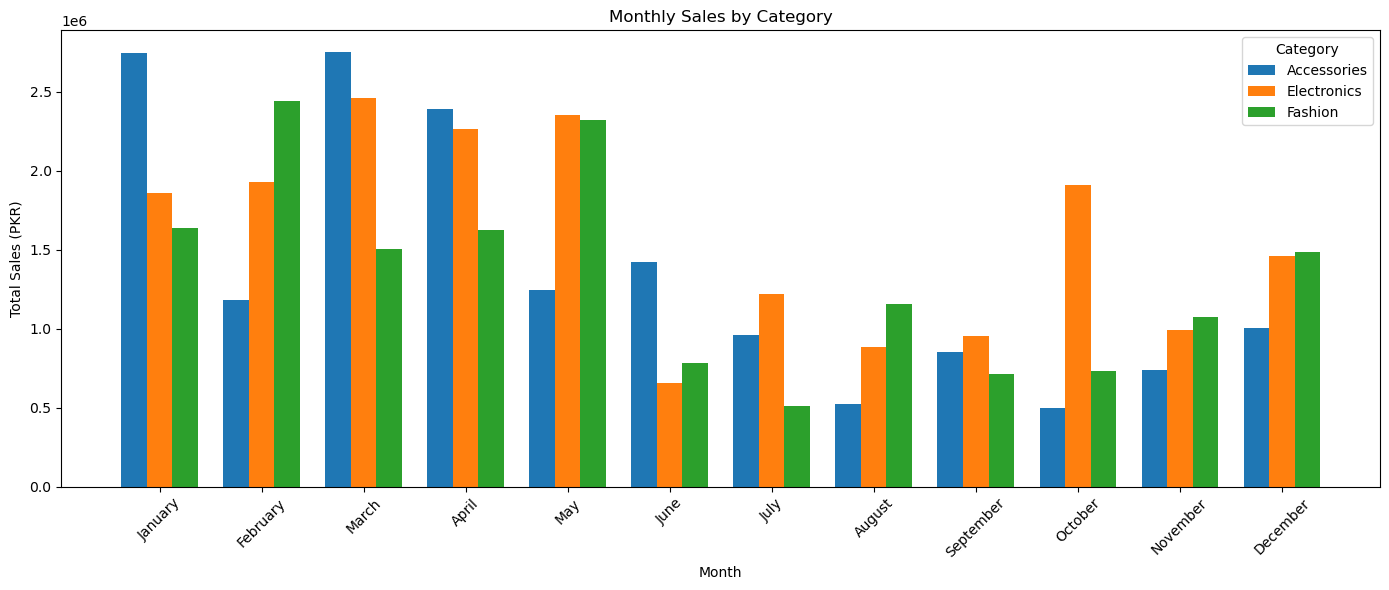

In [27]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

pivot = df.pivot_table(index='Month', columns='category',
                       values='total', aggfunc='sum').reindex(month_order)
print(pivot)

x = np.arange(len(month_order))
width = 0.25

plt.figure(figsize=(14, 6))
plt.bar(x - width, pivot['Accessories'], width, label='Accessories')
plt.bar(x,         pivot['Electronics'], width, label='Electronics')
plt.bar(x + width, pivot['Fashion'],     width, label='Fashion')

plt.title('Monthly Sales by Category')
plt.xlabel('Month')
plt.ylabel('Total Sales (PKR)')
plt.xticks(x, month_order, rotation=45)
plt.legend(title='Category')
plt.tight_layout()
plt.show()

Electronics is the largest category overall at PKR 18.93M (37.5% of total sales), ahead of Accessories (16.30M, 32.3%) and Fashion (15.97M, 31.6%) — a narrow spread indicating a balanced product mix with no category dependence. March is the strongest month for both Accessories (PKR 2.75M) and Electronics (2.46M), while Fashion peaks in February (2.44M). Category leadership rotates month to month rather than staying fixed: Accessories leads in January, March, April and June; Electronics in May, July, September and October; Fashion in February, August, November and December. Accessories is the most volatile category, swinging from a high of PKR 2.75M in March to a low of 0.50M in October — a 5.5x range — whereas Electronics is comparatively stable. October is notable as Electronics alone accounts for PKR 1.91M against only 0.50M for Accessories and 0.73M for Fashion, its most dominant month of the year. All three categories decline after May, consistent with the under-recording of second-half data identified in the month-wise analysis, so month-to-month comparisons across the June–December period should be treated with caution.